### E-Commerce Business Analysis

In [2]:
# Library
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import numpy as np
import scipy.stats
from sklearn.metrics import mean_squared_error
from math import sqrt
import os
from os import listdir
from datetime import datetime
import pandas as pd
from matplotlib.dates import DateFormatter
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from sklearn.linear_model import LinearRegression
import seaborn as sn
import plotly.express as px
import kagglehub
import seaborn as sns
print("listo ok")

listo ok


d:\Josefina\Proyectos\Datascience\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# El link se saca de lo que me dice kaggle antes
df = pd.read_csv("C:/Users/Josefina Urquiza/.cache/kagglehub/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr/versions/2/ecommerce_customer_behavior_dataset_v2.csv")

df

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17044,ORD_004999-1,CUST_04999,2024-01-16,44,Male,Antalya,Beauty,68.65,2,0.00,137.30,Digital Wallet,Mobile,14,10,False,6,1
17045,ORD_005000-1,CUST_05000,2023-02-22,24,Female,Eskisehir,Beauty,156.12,1,0.00,156.12,Credit Card,Mobile,15,8,True,7,5
17046,ORD_005000-2,CUST_05000,2023-06-29,24,Female,Eskisehir,Home & Garden,1065.24,3,0.00,3195.72,Credit Card,Desktop,17,11,True,5,4
17047,ORD_005000-3,CUST_05000,2023-12-29,24,Female,Eskisehir,Books,47.73,2,8.80,86.66,Credit Card,Desktop,13,11,True,12,2


####  01. Definicion del problema: 

El objetivo de este análisis es identificar los factores que influyen tanto en la recompra como en la facturación por compra, con el fin de comprender qué variables impulsan la rentabilidad del negocio.

A través del análisis de variables demográficas, de comportamiento de compra, comportamiento digital y experiencia post-compra, se buscará determinar qué características están asociadas a:

- Mayor probabilidad de volver a c.
- Mayor nivel de facturación por compra (Total_Amount).

Este conocimiento permitirá orientar decisiones comerciales, optimizar estrategias de retención y maximizar el valor generado por cada cliente.

## 02. Enfoque analítico

Dado que el objetivo es identificar los factores asociados a la recompra y a la facturación por compra, el análisis se estructurará en dos bloques:

- Variables de recompra.
- Variables de facturación por compra.

En ambos casos se explorarán relaciones entre variables demográficas, de comportamiento de compra, digitales y de experiencia post-compra.

BLOQUE 1: Variables de recompra
Variable objetivo: Is_Returning_Customer

Algunas preguntas:
- Los clientes recurrentes gastan más por compra?
- Tienen mejor rating?
- Sufren menos demoras?
- Usan más Mobile o Desktop?
- Compran ciertas categorías más que otras?
- Reciben más o menos descuentos?

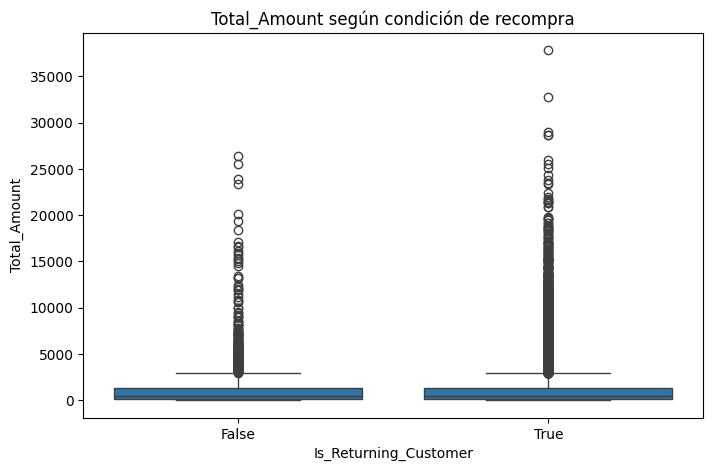

In [ ]:
# Recompra vs Facturación
# Queremos ver si los clientes recurrentes generan mayor ticket.

df.groupby("Is_Returning_Customer")["Total_Amount"].agg(["mean", "median", "std", "count"])

plt.figure(figsize=(8,5))
sns.boxplot(x="Is_Returning_Customer", y="Total_Amount", data=df)
plt.title("Total_Amount según condición de recompra")
plt.show()

<!-- Recompra vs Experiencia -->

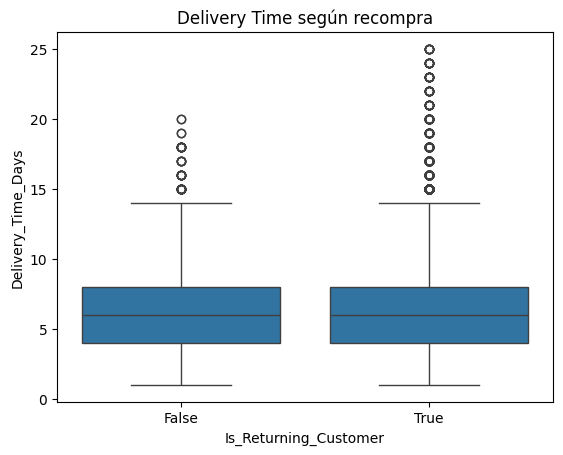

In [8]:
df.groupby("Is_Returning_Customer")["Delivery_Time_Days"].mean()

sns.boxplot(x="Is_Returning_Customer", y="Delivery_Time_Days", data=df)
plt.title("Delivery Time según recompra")
plt.show()

df.groupby("Is_Returning_Customer")["Customer_Rating"].mean()

sns.boxplot(x="Is_Returning_Customer", y="Customer_Rating", data=df)
plt.title("Rating según recompra")
plt.show()

Is_Returning_Customer
False    3.877612
True     3.902321
Name: Customer_Rating, dtype: float64


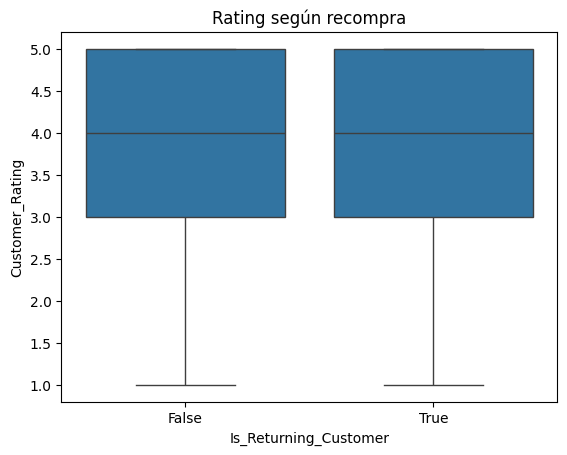

In [10]:
print(df.groupby("Is_Returning_Customer")["Customer_Rating"].mean())

sns.boxplot(x="Is_Returning_Customer", y="Customer_Rating", data=df)
plt.title("Rating según recompra")
plt.show()

Recompra vs Comportamiento Digital

In [11]:
pd.crosstab(df["Device_Type"], df["Is_Returning_Customer"], normalize="index")

Is_Returning_Customer,False,True
Device_Type,,
Desktop,0.115141,0.884859
Mobile,0.118621,0.881379
Tablet,0.123420,0.876580


Session_Duration

In [14]:
df.groupby("Is_Returning_Customer")["Session_Duration_Minutes"].mean()

Is_Returning_Customer
False    14.482090
True     14.542789
Name: Session_Duration_Minutes, dtype: float64

Pages_Viewed

In [15]:
df.groupby("Is_Returning_Customer")["Pages_Viewed"].mean()

Is_Returning_Customer
False    8.930348
True     9.012833
Name: Pages_Viewed, dtype: float64

Recompra vs Categoría

In [ ]:
# Esto te muestra qué categorías tienen mayor proporción de clientes recurrentes
pd.crosstab(df["Product_Category"], df["Is_Returning_Customer"], normalize="index")

Is_Returning_Customer,False,True
Product_Category,,
Beauty,0.115732,0.884268
Books,0.120127,0.879873
Electronics,0.119576,0.880424
Fashion,0.120623,0.879377
Food,0.112221,0.887779
Home & Garden,0.113107,0.886893
Sports,0.116103,0.883897
Toys,0.125837,0.874163


#### Recompra vs Discount

In [17]:
df.groupby("Is_Returning_Customer")["Discount_Amount"].mean()

Is_Returning_Customer
False    70.286368
True     69.721545
Name: Discount_Amount, dtype: float64

In [ ]:
df["Has_Discount"] = np.where(df["Discount_Amount"] > 0, 1, 0)

pd.crosstab(df["Has_Discount"], df["Is_Returning_Customer"], normalize="index")